## A/B Test
### Business question: ###

A marketing company wants to run a successful campaign to increase the company's revenue. Before running a full scale marketing campaign the company wants to test the idea and see if the marketing campaign make a significant difference. Marketing companies use A/B testing to evaluate the effectiveness of advertising campaigns. In an A/B test, users are randomly divided into two groups. The treatment group is shown the advertisement, while the control group sees a Public Service Announcement (PSA) or nothing in the same placement.

The company is interested in answering the question,
1. Would this be a successful campaign?


The goal of this analysis is to determine whether the ads increased conversions and test whether the difference between the two groups is statistically significant.

Data used: https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing/data 


#### Business objective: The ad campaign needs to produce at least a 40% relative improvement to be worth implementing. The baseline conversion rate is : $p_c=0.017854$ which is the conversion rate of the psa group (control group).  This means the ad campaign will be considered a success if conversion rate is improved by 40% so 0.0249956. 

In [1]:
#importing the libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import (proportion_effectsize, proportions_ztest, confint_proportions_2indep)
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.anova import anova_lm
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
import statsmodels.stats.api as sms
from math import ceil
from scipy.stats import norm
import plotly.graph_objects as go


np.random.seed(42)
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

In [22]:
#importing the data
df = pd.read_csv('marketing_AB.csv')

In [23]:
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


#### Data validation. Making sure that there aren't any duplicated user_ids

In [25]:
df['user id'].is_unique

True

checking for missing values

In [26]:
df.isna().sum()

Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [27]:
control_group = df[df['test group']=='psa']
treatment_group = df[df['test group']=='ad']

In [28]:
control_group.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23524 entries, 18 to 588081
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Unnamed: 0     23524 non-null  int64 
 1   user id        23524 non-null  int64 
 2   test group     23524 non-null  object
 3   converted      23524 non-null  bool  
 4   total ads      23524 non-null  int64 
 5   most ads day   23524 non-null  object
 6   most ads hour  23524 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 1.3+ MB


In [29]:
treatment_group.info()

<class 'pandas.core.frame.DataFrame'>
Index: 564577 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     564577 non-null  int64 
 1   user id        564577 non-null  int64 
 2   test group     564577 non-null  object
 3   converted      564577 non-null  bool  
 4   total ads      564577 non-null  int64 
 5   most ads day   564577 non-null  object
 6   most ads hour  564577 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 30.7+ MB


In [30]:
df['test group'].value_counts()

test group
ad     564577
psa     23524
Name: count, dtype: int64

### EDA (Exploratory Data Analysis)

#### calculating the conversion rates of the two groups

In [31]:
df.groupby('test group')['converted'].mean()


test group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64

In [32]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [33]:
df.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [36]:
df.rename(columns={
    'user id': 'user_id', 
    'test group':'test_group', 
    'total ads': 'total_ads', 
    'most ads day': 'most_ads_day',
    'most ads hour': 'most_ads_hour'}, inplace=True)

#### conversion rate by day

In [54]:
cr_day = (df.groupby(['most_ads_day','test_group'])['converted'].mean().unstack().reindex(weekday_order))

In [55]:
cr_day

test_group,ad,psa
most_ads_day,,
Monday,0.033241,0.022559
Tuesday,0.030440,0.014448
Wednesday,0.025356,0.015759
Thursday,0.021637,0.020230
Friday,0.022465,0.016303
Saturday,0.021307,0.013996
Sunday,0.024620,0.020595


plotting this information

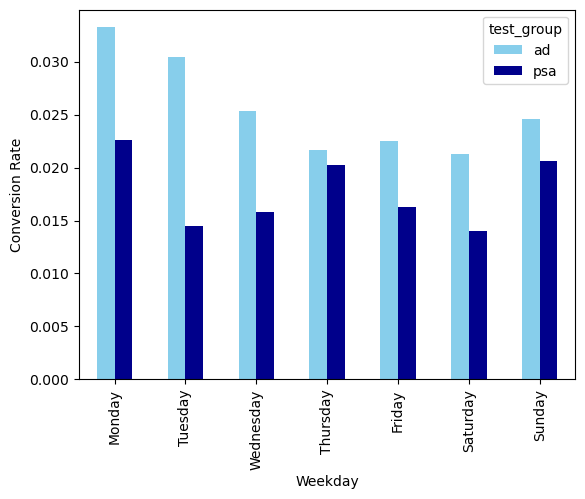

In [56]:
cr_day.plot(kind='bar', color=['skyblue', 'darkblue'])
plt.xlabel('Weekday')
plt.ylabel('Conversion Rate')
plt.show()

conversion rate by hour for the treatement group (group shown the ads)

In [76]:
cr_hour = df.groupby(['most_ads_hour', 'test_group'])['converted'].mean().unstack()
#cr_hour

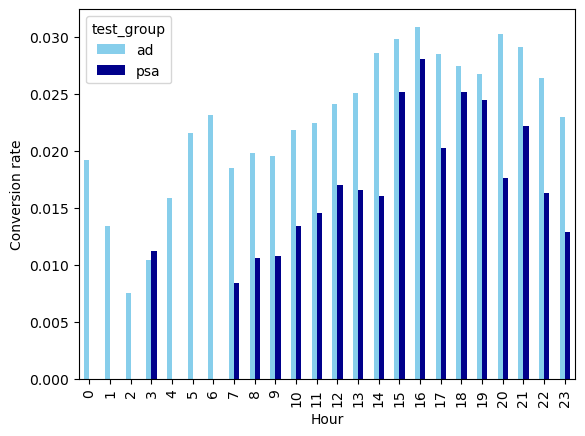

In [75]:
cr_hour.plot(kind='bar', color=['skyblue','darkblue'])
plt.xlabel('Hour')
plt.ylabel('Conversion rate')
plt.show()

In [78]:
control_group = df[df['test_group']=='psa']
treatment_group = df[df['test_group']=='ad']

#### plotting the conversion rates for the treatment group for days and hours

In [79]:
cr_hour_day_ad = (treatment_group.groupby(['most_ads_day', 'most_ads_hour'])['converted'].mean().unstack().reindex(weekday_order).T)
cr_hour_day_ad

most_ads_day,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
most_ads_hour,,,,,,,
0,0.017073,0.019635,0.011905,0.025424,0.019827,0.023591,0.016484
1,0.016949,0.014241,0.008389,0.018813,0.010574,0.008547,0.017544
2,0.007052,0.005495,0.004847,0.013177,0.012121,0.004444,0.005814
3,0.012658,0.020833,0.003030,0.005510,0.003883,0.011050,0.019022
4,0.000000,0.020000,0.020000,0.027523,0.016949,0.000000,0.020000
5,0.032609,0.013158,0.007143,0.021978,0.015504,0.056818,0.015873
6,0.041985,0.022624,0.013966,0.021053,0.012121,0.051587,0.007220
7,0.018421,0.021948,0.011905,0.015920,0.018664,0.023384,0.020202
8,0.033997,0.018242,0.016616,0.015062,0.016539,0.023256,0.016368


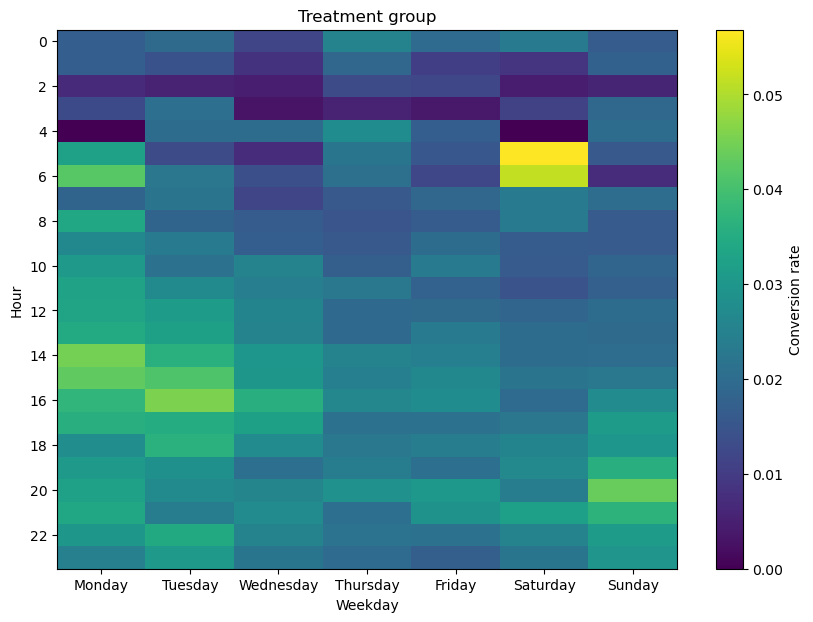

In [81]:
plt.figure(figsize=(10, 7))
plt.imshow(cr_hour_day_ad, aspect='auto')
plt.xticks(range(len(weekday_order)), weekday_order)
plt.yticks(range(0, 24, 2))
plt.xlabel('Weekday')
plt.ylabel('Hour')
plt.title('Treatment group')
plt.colorbar(label='Conversion rate')
plt.show()

In [82]:
dist_day_sample = df.groupby(['most_ads_day', 'test_group']).size().unstack().reindex(weekday_order)
dist_day_sample

test_group,ad,psa
most_ads_day,,
Monday,83571,3502
Tuesday,74572,2907
Wednesday,77418,3490
Thursday,79077,3905
Friday,88805,3803
Saturday,78802,2858
Sunday,82332,3059


### Statistical Analysis

#### Question: Does the campaign increase the conversion rate? In other words is the conversion rate in the treatment group higher than the conversion rate in the control group?

Since we are comparing conversion rates (proportions) of the control and treatment groups we will use **Two proportion Z test**.

Hypothesis testing: Right-tailed Z test\
$H_0: p_T \leq p_c$\
$H_1: p_T > p_c$


#### Exploring the Data


In [104]:
print("Sample sizes\n")
ad = df[df['test_group']=='ad']
psa = df[df['test_group']=='psa']

print('sample size of ad group  :%d'%len(ad))
print('sample size of psa group :%d'%len(psa))

ad_rate = ad['converted'].mean()
psa_rate = psa['converted'].mean()
print('conversion rates\n')
print('conversion rate for ad group  :%f'%ad_rate)
print('conversion rate for psa group :%f'%psa_rate)


Sample sizes

sample size of ad group  :564577
sample size of psa group :23524
conversion rates

conversion rate for ad group  :0.025547
conversion rate for psa group :0.017854


#### Business objective

For the ad campaign to be implemented there should be atleast a 40% increase in the conversion rate. 



In [111]:
target_ad_rate = psa_rate*(1.4)

print("Baseline psa rate : %f"%psa_rate)
print("Target ad rate    : %f"%target_ad_rate)


Baseline psa rate : 0.017854
Target ad rate    : 0.024996


#### Power analysis


#### Choosing the sample size: The sample sizes are already determined. But we could use the existing sample sizes and calculate the achieved power with the existing sample sizes. 

Since we are not testing the whole user base (population), the conversion rates will differ from the true rates. The number of people we have for each group will have an effect on the precision of the estimated conversion rates: the larger the sample size, more precise the estimates (smaller confidence intervals), the higher the chance to detect a difference in the two groups. 

But the larger the sample size, the more expensive (and impractical) the study becomes. Therefore a sample size is estimated through power analysis which depends on a few factors: 

1. Power of the test $(1-\beta)$ - This represents the probability of finding a statistical difference between the groups in our test when a difference is actually present. This is usually set at 0.8 as a convention. eg: If showing ads truly improves conversion rates, I want my experiment to detect that improvement 80% of the time.
2. Alpha value $(\alpha)$ set to 0.05. We'll set a confidence level of 95%. That means a significance level of 5%. $\alpha$ is the decision threshold. I am willing to accept a 5% chance of incorrectly rejecting the null hypothesis (Type I error or False positive)
3. Effect size - How big of a difference we expect there to be between the conversion rates

Since the business team would be happy with a conversion rate lift of 40%, we can use baseline pas rate of 0.017854 and target conversion rate of 0.024996 to calculate the effect size. 

Since the samples are already given, we can use it to find the achieved power. 

In [135]:
alpha = 0.05
power = 0.8

#current sample sizes for the psa and ad groups
ad_n = len(ad)
psa_n = len(psa)

effect_size = proportion_effectsize(target_ad_rate, psa_rate)

# calculating the current sample ratio
ratio = psa_n/ad_n

#achieved power
achieved_power = analysis.power(
    effect_size = effect_size,
    nobs1 = ad_n,
    alpha = alpha,
    ratio = ratio,
    alternative = 'larger'
)

print("Achieved power with current data: %f"%achieved_power)


Achieved power with current data: 1.000000


This means that with the current sample sizes, the estimated probability of detecting a 40% increase in the conversion rate is 100%. 

### Testing the hypothesis

we will perform a right-tailed z test since we are testing whether the conversion rate for the ad group(treatment group) is higher than the conversion rate for the psa group(control group). 

$p_T>p_C$ 

In [139]:
#importing the necessary libraries
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

In [137]:
control_results = df[df['test_group'] == 'psa']['converted']   #psa group
treatment_results = df[df['test_group'] == 'ad']['converted']  # ad group

In [166]:
alpha=0.05
n_con = control_results.count()
n_treat = treatment_results.count()
successes = [treatment_results.sum(), control_results.sum()]    #summing all the 1s and 0s for each group. eg: successes=[3,4] -> 3 conversion for control, 4 for treatment
nobs = [n_treat, n_con]             #sample sizes. eg: nobs=[10, 10]

z_stat, pval = proportions_ztest(successes, nobs=nobs, alternative='larger')    # 'larger' tests whether the first proportion (ad group) is larger than the psa group(control group)

#calculating the confidence intervals
(lower_con, lower_treat), (upper_con, upper_treat) = proportion_confint(successes, nobs=nobs, alpha=0.05)

#calculating the critical value
z_crit = norm.ppf(1 - alpha)

#p_value conclusion
p_val_conclusion = ['Fail to Reject $H_0$' if pval>alpha else 'Reject $H_0$']
#stat conclusions
stat_conclusion = ['Fail to Reject $H_0$' if z_stat<z_crit else 'Reject $H_0$']


In [167]:
#printing out the results
frame = pd.DataFrame(
       {'value':[z_stat,z_crit,alpha,f'{pval:0.2e}',p_val_conclusion,stat_conclusion]},
       index=['z_stat', 'critical value','alpha','p-value', 'p-value conclusion','stat conclusion'])
frame 

,value
z_stat,7.370078
critical value,1.644854
alpha,0.05
p-value,8.53e-14
p-value conclusion,[Reject $H_0$]
stat conclusion,[Reject $H_0$]


**This means that the ad conversion rate is statistically significantly higher than the PSA conversion rate (baseline rate).**


### Z test visualization

In [164]:
def z_test_visualization(z_stat,p_value,alpha=0.05,alternative='two-sided',title='One Sample Z-Test'):
    # Standard normal distribution
    x = np.arange(-8, 8, 0.01)
    y = norm.pdf(x)

    fig = go.Figure()

    # Colors
    rejection_color = "#FF6B6B"
    accept_color = "#4ECDC4"
    critical_line_color = "#f5b00f"   #FFD166"
    statistic_line_color = "#000000"  #FFFFFF"

    ####################################################
    # Two-tailed test
    ####################################################
    if alternative == "two-sided":

        crit_left = norm.ppf(alpha / 2)   # ppf:percent point function. inverse cumulative distribution function. What Z-score has 2.5% of the distribution to its left?
        crit_right = norm.isf(alpha / 2)  # isf:inverse survival function.What Z-score has 2.5% of the distribution to its right.

        # Left rejection region
        mask = x <= crit_left
        fig.add_trace(go.Scatter(
            x=x[mask],
            y=y[mask],
            fill='tozeroy',  # fill all the way to y=0
            mode='lines',
            line=dict(width=0),
            fillcolor=rejection_color,
            showlegend=False
        ))

        # Acceptance region
        mask = (x >= crit_left) & (x <= crit_right)
        fig.add_trace(go.Scatter(
            x=x[mask],
            y=y[mask],
            fill='tozeroy',
            mode='lines',
            line=dict(width=0),
            fillcolor=accept_color,
            showlegend=False
        ))

        # Right rejection region
        mask = x >= crit_right
        fig.add_trace(go.Scatter(
            x=x[mask],
            y=y[mask],
            fill='tozeroy',
            mode='lines',
            line=dict(width=0),
            fillcolor=rejection_color,
            showlegend=False
        ))

        # Critical values
        fig.add_vline(x=crit_left,line_dash='dash',line_color=critical_line_color)
        fig.add_vline(x=crit_right,line_dash='dash',line_color=critical_line_color)
        critical_text = f"{crit_left:.2f}, {crit_right:.2f}"

    ####################################################
    # Right-tailed test
    ####################################################
    elif alternative == "right-tailed":

        crit = norm.isf(alpha)   #What Z-score has 5% of the distribution to its right?

        # Acceptance region
        mask = x <= crit
        fig.add_trace(go.Scatter(
            x=x[mask],
            y=y[mask],
            fill='tozeroy',
            mode='lines',
            line=dict(width=0),
            fillcolor=accept_color,
            showlegend=False
        ))

        # Rejection region
        mask = x >= crit
        fig.add_trace(go.Scatter(
            x=x[mask],
            y=y[mask],
            fill='tozeroy',
            mode='lines',
            line=dict(width=0),
            fillcolor=rejection_color,
            showlegend=False
        ))

        fig.add_vline(x=crit,line_dash='dash',line_color=critical_line_color)
        critical_text = f"{crit:.2f}"

    ####################################################
    # Left-tailed test
    ####################################################
    elif alternative == "left-tailed":

        crit = norm.ppf(alpha)   #What Z-score has 5% of the distribution to its right?

        # Acceptance region
        mask = x >= crit
        fig.add_trace(go.Scatter(
            x=x[mask],
            y=y[mask],
            fill='tozeroy',
            mode='lines',
            line=dict(width=0),
            fillcolor=accept_color,
            showlegend=False
        ))

        # Rejection region
        mask = x <= crit
        fig.add_trace(go.Scatter(
            x=x[mask],
            y=y[mask],
            fill='tozeroy',
            mode='lines',
            line=dict(width=0),
            fillcolor=rejection_color,
            showlegend=False
        ))

        fig.add_vline(x=crit,line_dash='dash',line_color=critical_line_color)
        critical_text = f"{crit:.2f}"

    
    else:
        raise ValueError("alternative must be 'two-sided','right-tailed' or 'left-tailed'")

    ####################################################
    # Distribution curve
    ####################################################
    fig.add_trace(go.Scatter(
        x=x,
        y=y,
        mode='lines',
        line=dict(color='black', width=2),
        showlegend=False
    ))

    ####################################################
    # Test statistic
    ####################################################
    fig.add_vline(x=z_stat,line_width=3,line_color=statistic_line_color)

    ####################################################
    # Decision
    ####################################################
    conclusion = ("Reject H₀" if p_value <= alpha else "Fail to Reject H₀")

    fig.add_annotation(x=z_stat,y=0.35,
        text=(
            f"<b>Z = {z_stat:.2f}</b><br>"
            f"p-value = {p_value:0.2e}<br>"
            f"{conclusion}"
        ),
        showarrow=True,
        arrowhead=2,
        bgcolor="black",
        font=dict(color="white")
    )

    ####################################################
    # Layout
    ####################################################
    fig.update_layout(
        title=f"{title}<br>α = {alpha}, Critical Value(s): {critical_text}",
        xaxis_title="Z",
        yaxis_title="Density",
        template="plotly_white",
        width=850,
        height=550,
        showlegend=False
    )

    fig.update_xaxes(range=[-8, 8])
    fig.update_yaxes(range=[0, 0.45])

    return fig

#### plotting the z test visualization

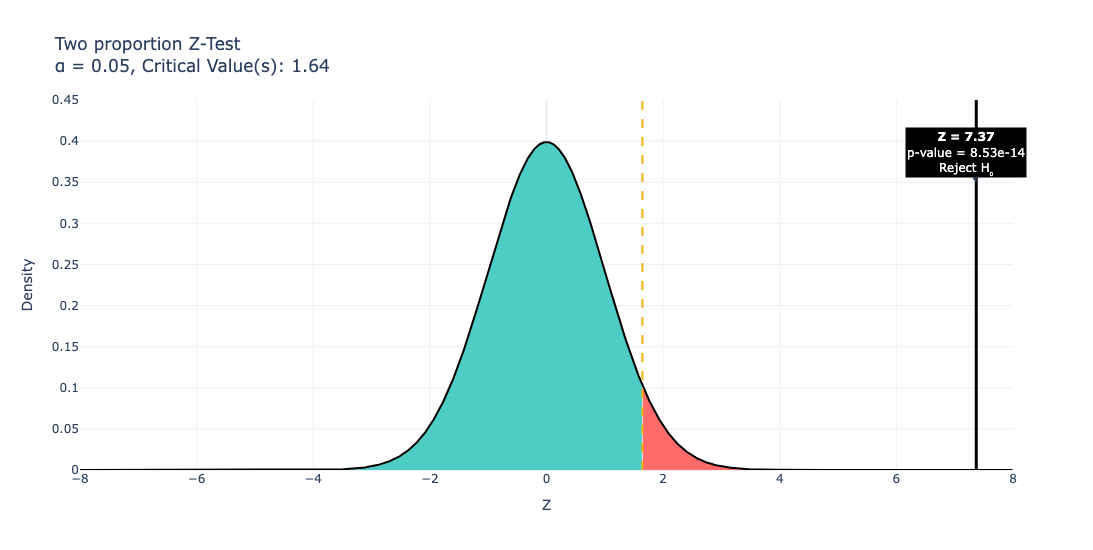

In [165]:
z_test_visualization(z_stat,pval,alpha=0.05,alternative='right-tailed',title='Two proportion Z-Test')

In [160]:
#printing out the results
frame = pd.DataFrame(
       {'value':[z_stat,z_crit,alpha,f'{pval:0.2e}',p_val_conclusion,stat_conclusion]},
       index=['z_stat', 'critical value','alpha','p-value', 'p-value conclusion','stat conclusion'])
frame 

,value
z_stat,7.370078
critical value,1.644854
alpha,0.05
p-value,8.53e-14
p-value conclusion,[Reject $H_0$]
stat conclusion,[Reject $H_0$]


#### Conclusion :

Our hypothesis:

$H_0: p_T \leq p_c$\
$H_1: p_T > p_c$

The right tailed two proportion z test found statistically significant (5% significance level) evidence (z = 7.37, p_value = 8.53e-14) that the conversion rate in the treatment group (ad group) is higher than the conversion rate in the control group (psa group). Hence the null hypothesis was rejected in favor of the alternate hypothesis. 
